# `maws.space` tutorial

A guided tour of the surface-aware sampler that MAWS uses to pick the
initial pose of an aptamer relative to its target. By the end of this
notebook you will know:

1. What `make_sampler` returns and how to call it.
2. How candidate poses are generated and filtered.
3. The two sampling modes (`"sphere"` and `"surface-following"`) and
   when to pick each.
4. How to tune the parameters that matter (`reach`, `d_max`, `probe`).

We work on a real protein-aptamer co-crystal,
[**1HAO**](https://www.rcsb.org/structure/1HAO): human alpha-thrombin
bound to the 15-mer DNA aptamer TBA. The bound aptamer is hidden from
the sampler and used as a visual anchor so you can see where the
sampler concentrates its poses relative to a real binding region.


## 1. Setup

Run this notebook from inside the `maws` conda environment. It lives
at `notebooks/space_analysis.ipynb`.


In [1]:
import logging
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from openmm import unit
from openmm.app import PDBFile
from scipy.spatial import KDTree

from maws import space
from maws.complex import Complex
from maws.helpers import mass_weighted_center, nostrom
from maws.pdb_cleaner import resolve_pdb_path

# Resolve paths from repo root.
os.chdir("..")
np.random.seed(0)

## 2. Loading a target

1HAO contains seven chains. Two matter for our purposes:

* Chains `L` and `H` are the two thrombin polypeptides. In MAWS
  terminology this is the *ligand*: the static target around which
  poses are drawn.
* Chain `D` is the bound DNA aptamer (TBA, sequence
  `GGTTGGTGTGGTTGG`). MAWS would not normally have this in a real
  run, but here we keep its atomic positions aside as a visual
  reference so you can see where the sampler concentrates its poses
  relative to a known binding site.

The other chains are crystallographic waters, ions, and a small
inhibitor (`0G6`), all dropped in section 3.


In [2]:
raw = PDBFile("data/1HAO.pdb")

chain_atoms = defaultdict(list)
for atom in raw.topology.atoms():
    pos_ang = np.array(raw.positions[atom.index].value_in_unit(unit.nanometer)) * 10.0
    chain_atoms[atom.residue.chain.id].append(
        (atom.element.symbol, pos_ang, atom.residue.name)
    )

print("Chains in 1HAO:")
for cid, atoms in chain_atoms.items():
    resnames = sorted({rn for _, _, rn in atoms})
    if any(r in {"DA", "DT", "DG", "DC"} for r in resnames):
        kind = "DNA aptamer"
    elif resnames == ["HOH"]:
        kind = "waters"
    elif resnames == ["0G6"]:
        kind = "inhibitor"
    else:
        kind = "protein"
    print(f"  chain {cid!r:>3}: {len(atoms):4d} atoms  ({kind})")

# Aptamer reference: chain D, DNA residues only.
APTAMER_POS = np.array(
    [p for _, p, rn in chain_atoms["D"] if rn in {"DA", "DT", "DG", "DC"}]
)
print(f"\nAptamer atoms (visual reference): {len(APTAMER_POS)}")

Chains in 1HAO:
  chain 'D':  334 atoms  (DNA aptamer)
  chain 'L':  233 atoms  (protein)
  chain 'H': 2202 atoms  (protein)

Aptamer atoms (visual reference): 315


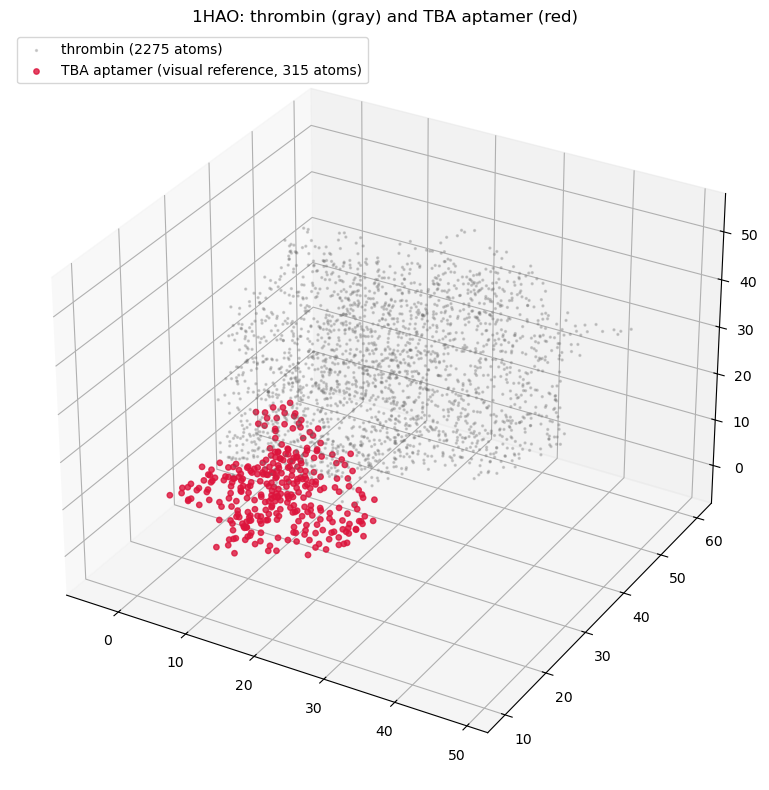

In [3]:
# Visual sanity check: protein in gray, aptamer in red.
prot_pos_raw = np.array(
    [
        p
        for cid in ("L", "H")
        for _, p, rn in chain_atoms[cid]
        if rn not in {"HOH", "0G6"}
    ]
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    *prot_pos_raw.T,
    s=2,
    alpha=0.25,
    color="#666",
    label=f"thrombin ({len(prot_pos_raw)} atoms)",
)
ax.scatter(
    *APTAMER_POS.T,
    s=15,
    alpha=0.8,
    color="crimson",
    label=f"TBA aptamer (visual reference, {len(APTAMER_POS)} atoms)",
)
ax.set_title("1HAO: thrombin (gray) and TBA aptamer (red)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3. Building the ligand `Complex`

MAWS uses `maws.complex.Complex` to hold a parameterized molecular
system. For our walkthrough we want only thrombin (with no aptamer or
crystallographic noise), so we run the raw PDB through
`resolve_pdb_path` first to:

* keep only chains `L` and `H` (drop the aptamer and inhibitor),
* remove crystallographic hydrogens (LEaP will rebuild them),
* drop HETATM records (waters, ions, the inhibitor).

Then we pass the cleaned PDB to `Complex.add_chain_from_pdb` and call
`Complex.build()`. The build runs LEaP under the hood to assign
force-field parameters, and OpenMM to load the resulting topology and
coordinates. After this, `ligand_only.positions` and
`ligand_only.topology` are what the sampler will read.

The build is cached, so re-running this cell after the first run is
instant.


In [4]:
clean_path, _ = resolve_pdb_path(
    "data/1HAO.pdb",
    molecule_type="protein",
    clean_pdb=True,
    keep_chains="L,H",
    remove_h=True,
    drop_hetatm=True,
    logger=logging.getLogger("walkthrough"),
)

ligand_only = Complex(
    force_field_aptamer="leaprc.DNA.OL21",
    force_field_ligand="leaprc.protein.ff19SB",
)
ligand_only.add_chain_from_pdb(
    pdb_path=clean_path,
    force_field_aptamer="leaprc.DNA.OL21",
    force_field_ligand="leaprc.protein.ff19SB",
    parameterized=True,
)
ligand_only.build()

PROT_POS = np.asarray(nostrom(ligand_only.positions), dtype=float)
n_res = sum(1 for _ in ligand_only.topology.residues())
print(f"Built thrombin Complex: {len(PROT_POS)} atoms, {n_res} residues")

-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/prep to search path.
-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/lib to search path.
-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/parm to search path.
-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/cmd to search path.
-f: Source leap.in.

Welcome to LEaP!
(no leaprc in search path)
Sourcing: ./leap.in
----- Source: /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.DNA.OL21
----- Source of /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.DNA.OL21 done
Log file: ./leap.log
Loading library: /home/siddharth/miniforge3/envs/maws/dat/leap/lib/ff-nucleic-OL21.lib
Loading parameters: /home/siddharth/miniforge3/envs/maws/dat/leap/parm/parm10.dat
Reading title:
PARM99 + frcmod.ff99SB + frcmod.parmbsc0 + OL3 for RNA
Loading parameters: /home/siddharth/miniforge3/envs/maws/dat/leap/parm/ff-nucleic-OL21.frcmod
Reading force field modification type file (frcmod)
Reading title:
OL21 force field 

Built thrombin Complex: 3937 atoms, 244 residues


/home/siddharth/miniforge3/envs/maws/lib/python3.11/site-packages/openmm/app/internal/amber_file_parser.py:1165: UserWarning: Non-optimal GB parameters detected for GB model OBC1
  warnings.warn(
/home/siddharth/work/MAWS_2025/maws/complex.py:445: RuntimeWarning: Platform 'CUDA' unavailable: There is no registered Platform called "CUDA"
  self.simulation = self._create_simulation()
/home/siddharth/work/MAWS_2025/maws/complex.py:445: RuntimeWarning: Platform 'OpenCL' unavailable: There is no registered Platform called "OpenCL"
  self.simulation = self._create_simulation()


### Quick sanity check that coordinate frames agree

We will overlay the aptamer (loaded from the raw PDB) on the
post-build protein atoms. For that to be meaningful, both must live in
the same coordinate frame. A Kabsch alignment between the cleaned
heavy atoms and the post-build heavy atoms confirms the build
preserves coordinates exactly.


In [5]:
cleaned = PDBFile(clean_path)

# Pair atoms by (residue-sequence-position, atom name).
pre_idx, post_idx = {}, {}
for ri, res in enumerate(cleaned.topology.residues()):
    for a in res.atoms():
        p_ang = (
            np.array(cleaned.positions[a.index].value_in_unit(unit.nanometer)) * 10.0
        )
        pre_idx[(ri, a.name)] = p_ang
for ri, res in enumerate(ligand_only.topology.residues()):
    for a in res.atoms():
        post_idx[(ri, a.name)] = PROT_POS[a.index]

matched = [(pre_idx[k], post_idx[k]) for k in pre_idx if k in post_idx]
src = np.array([m[0] for m in matched])
dst = np.array([m[1] for m in matched])
src_mean, dst_mean = src.mean(0), dst.mean(0)
covariance = (src - src_mean).T @ (dst - dst_mean)
u, _, vt = np.linalg.svd(covariance)
chirality = np.sign(np.linalg.det(vt.T @ u.T))
rotation = vt.T @ np.diag([1, 1, chirality]) @ u.T
translation = dst_mean - rotation @ src_mean
rmsd = float(np.sqrt((((rotation @ src.T).T + translation - dst) ** 2).sum(1).mean()))

print("Kabsch alignment of cleaned heavy atoms to post-build heavy atoms:")
print(f"  translation:   {translation}  (expect approximately 0)")
print(f"  |R - I| max:   {np.abs(rotation - np.eye(3)).max():.6f}  (expect 0)")
print(f"  RMSD:          {rmsd:.6f} Å  (expect 0)")

Kabsch alignment of cleaned heavy atoms to post-build heavy atoms:
  translation:   [-3.55271368e-15 -7.10542736e-15 -7.10542736e-15]  (expect approximately 0)
  |R - I| max:   0.000000  (expect 0)
  RMSD:          0.000000 Å  (expect 0)


## 4. What the sampler does

The job of `maws.space` is to draw candidate positions and rotations
for an aptamer atom, given a static protein target. Each draw is a
`Sample`:

```python
@dataclass(frozen=True)
class Sample:
    position: np.ndarray  # shape (3,), Å
    axis: np.ndarray      # shape (3,), unit vector
    angle: float          # radians
```

A "good" sample is one that does not put the aptamer atom inside the
protein bulk. The library has one entry point, `make_sampler`, that
builds a configured sampler from a `Complex`:

```python
sampler = space.make_sampler(complex_obj, mode="sphere", reach=10.0, probe=1.4)
pose = sampler.generator()
print(pose.position, pose.axis, pose.angle)
```

Internally there are two modes:

| mode | how it works |
|---|---|
| `"sphere"` (default) | Draws uniformly in a bounding sphere around the protein. Rejects samples that clash with any protein atom (SAS check with `probe` and Bondi vdW radii). |
| `"surface-following"` (opt-in) | Same SAS rejection, plus an outer cap that rejects samples more than `d_max` Å from any protein atom. Accepted samples concentrate near the surface. |

Both modes return objects with a `.generator() -> Sample` method.
Calling code does not branch on the mode.

The next sections walk through the geometry that `make_sampler` reads
out of the `Complex`, then show each mode in action.


## 5. Geometry the sampler reads

Both modes auto-size from two scalars derived from the protein atoms:

* `COM`: mass-weighted centre of mass.
* `R_max`: distance from `COM` to the farthest atom.

Plus the user's `reach` (sphere mode) or `d_max` (surface-following
mode). The histogram below shows how the protein atoms are
distributed in radius from the COM.


Mass-weighted COM: [20.74021228 35.50588262 29.88118437]
R_max = 31.81 Å (thrombin's hydrodynamic radius is about 25 Å)
Sphere envelope radius at reach=10: 41.81 Å


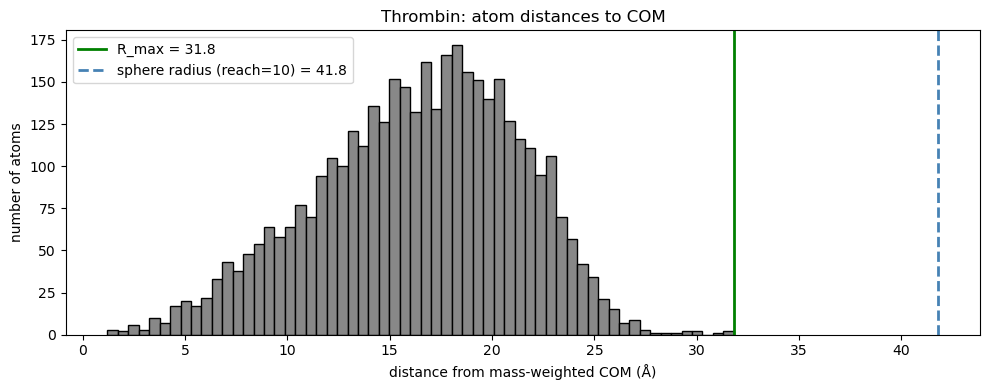

In [6]:
masses = np.array(
    [a.element.mass.value_in_unit(unit.dalton) for a in ligand_only.topology.atoms()]
)
COM = mass_weighted_center(PROT_POS, masses)
dists = np.linalg.norm(PROT_POS - COM, axis=1)
R_MAX = float(dists.max())

print(f"Mass-weighted COM: {COM}")
print(f"R_max = {R_MAX:.2f} Å (thrombin's hydrodynamic radius is about 25 Å)")
print(f"Sphere envelope radius at reach=10: {R_MAX + 10:.2f} Å")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dists, bins=60, color="#888", edgecolor="black")
ax.axvline(R_MAX, color="green", lw=2, label=f"R_max = {R_MAX:.1f}")
ax.axvline(
    R_MAX + 10,
    color="steelblue",
    lw=2,
    ls="--",
    label=f"sphere radius (reach=10) = {R_MAX + 10:.1f}",
)
ax.set_xlabel("distance from mass-weighted COM (Å)")
ax.set_ylabel("number of atoms")
ax.set_title("Thrombin: atom distances to COM")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Sphere mode in action

This is the default. `make_sampler(complex_obj)` returns a
`SurfaceSampler` that:

1. Draws candidate positions uniformly inside the bounding sphere
   (radius `R_max + reach`, centred on `COM`).
2. Rejects candidates that fall inside the protein's SAS envelope,
   i.e. inside `vdW + probe` of any protein atom.

Below we draw 2000 raw candidates and colour them by whether the SAS
check accepted them. Red points are inside the protein bulk; green
points are clear.


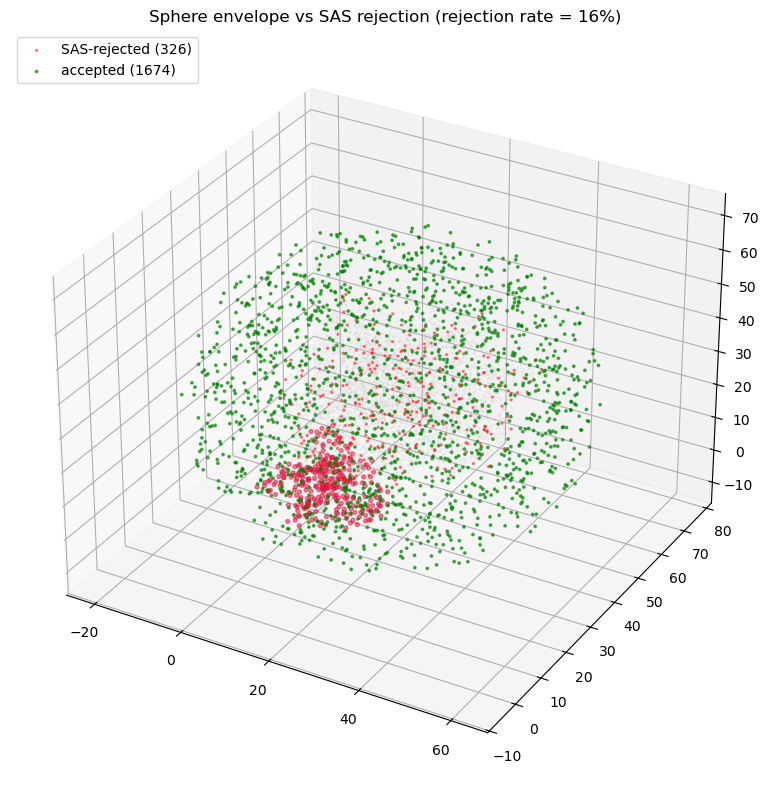

In [7]:
REACH = 10.0
PROBE = 1.4
N_RAW = 2000

excluder = space.Excluder(ligand_only, probe=PROBE)
envelope = space.Sphere(**space.compute_envelope_dims(ligand_only, reach=REACH))

pts = np.array([envelope.generator().position for _ in range(N_RAW)])
clear = np.array([excluder.is_clear(p) for p in pts])
rate = (~clear).sum() / N_RAW

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(*PROT_POS.T, s=1, alpha=0.1, color="#bbb")
ax.scatter(*APTAMER_POS.T, s=8, alpha=0.5, color="crimson")
ax.scatter(
    *pts[~clear].T,
    s=2,
    alpha=0.4,
    color="red",
    label=f"SAS-rejected ({(~clear).sum()})",
)
ax.scatter(
    *pts[clear].T, s=3, alpha=0.6, color="green", label=f"accepted ({clear.sum()})"
)
ax.set_title(f"Sphere envelope vs SAS rejection (rejection rate = {rate:.0%})")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 7. Surface-following mode in action

`mode="surface-following"` returns a `SurfaceFollowingSampler` that
adds one more rejection criterion: a candidate is rejected if it sits
more than `d_max` Å from any protein atom. So accepted samples form a
layer of thickness `d_max` wrapping the protein.

The plot below shows 1500 accepted samples from each mode, side by
side, on the same protein.


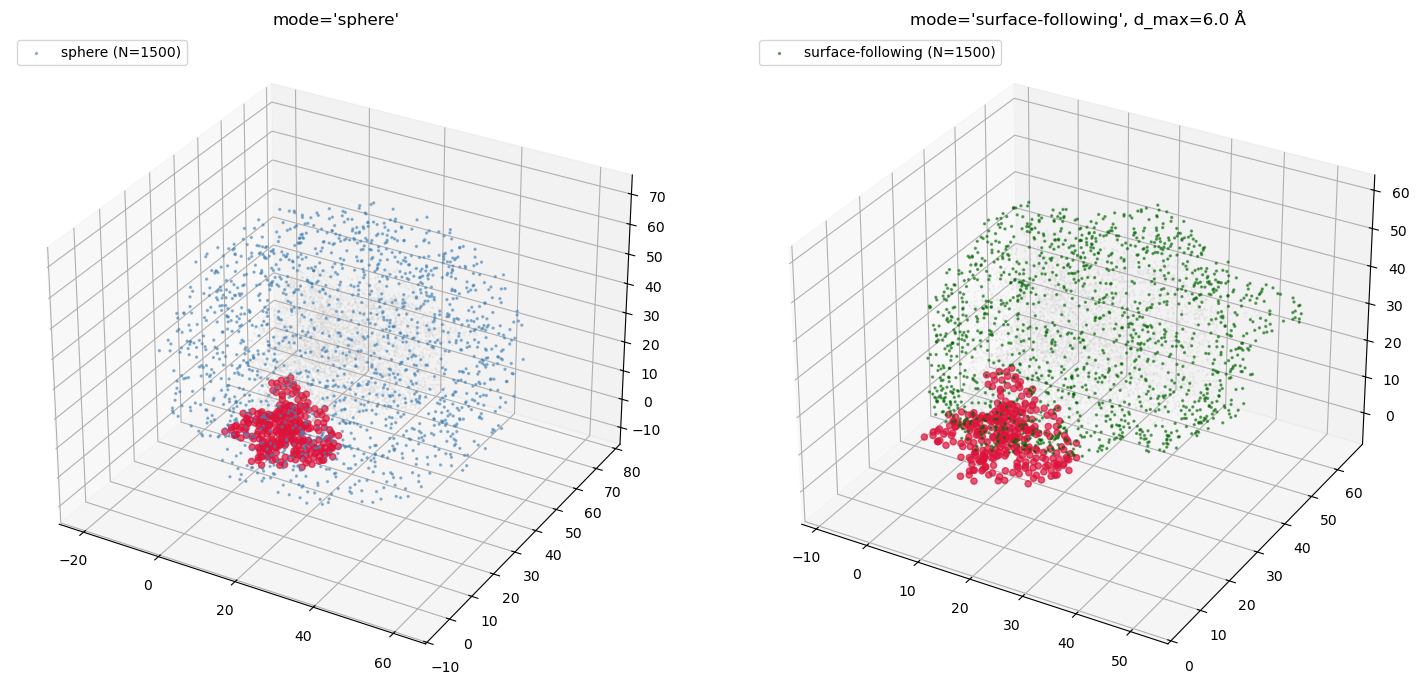

In [8]:
N_VIS = 1500
D_MAX_VIS = 6.0

np.random.seed(0)
sphere_sampler = space.make_sampler(
    ligand_only, mode="sphere", reach=REACH, probe=PROBE
)
sphere_pts = np.array([sphere_sampler.generator().position for _ in range(N_VIS)])

np.random.seed(0)
sf_sampler = space.make_sampler(
    ligand_only, mode="surface-following", d_max=D_MAX_VIS, probe=PROBE
)
sf_pts = np.array([sf_sampler.generator().position for _ in range(N_VIS)])

fig = plt.figure(figsize=(15, 7))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.scatter(*PROT_POS.T, s=1, alpha=0.08, color="#aaa")
ax.scatter(*APTAMER_POS.T, s=20, alpha=0.7, color="crimson")
ax.scatter(
    *sphere_pts.T, s=2, alpha=0.5, color="steelblue", label=f"sphere (N={N_VIS})"
)
ax.set_title("mode='sphere'")
ax.legend(loc="upper left")

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(*PROT_POS.T, s=1, alpha=0.08, color="#aaa")
ax.scatter(*APTAMER_POS.T, s=20, alpha=0.7, color="crimson")
ax.scatter(
    *sf_pts.T, s=2, alpha=0.5, color="darkgreen", label=f"surface-following (N={N_VIS})"
)
ax.set_title(f"mode='surface-following', d_max={D_MAX_VIS} Å")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

The blue cloud on the left fills the entire bounding sphere,
including the far solvent. The green cloud on the right hugs the
protein surface and follows into pockets, including the region where
the TBA aptamer sits in red.

Surface-following pays for this concentration with a higher rejection
rate: it rejects everything more than `d_max` from any atom *and*
everything inside the protein.


## 8. How the modes compare quantitatively

To make the visual difference concrete, here is one quantitative
comparison on this protein: for each sampler we draw 5000 accepted
poses and measure what fraction land within 5, 10, 15, or 20 Å of the
nearest TBA aptamer atom (our reference for "binding-relevant
region"). We also sweep `d_max` to show how the band thickness
affects coverage.

The numbers below are illustrative for one protein and one binding
region. They should give you a feel for the order of magnitude of the
tradeoff, not a universal benchmark.


In [9]:
N_BENCH = 5000


def coverage(positions, apt_pos):
    nearest, _ = KDTree(apt_pos).query(positions, k=1)
    return {
        "<=5 A": float((nearest <= 5).mean()),
        "<=10 A": float((nearest <= 10).mean()),
        "<=15 A": float((nearest <= 15).mean()),
        "<=20 A": float((nearest <= 20).mean()),
        "median": float(np.median(nearest)),
    }


rows = []
np.random.seed(0)
s = space.make_sampler(ligand_only, mode="sphere", reach=REACH, probe=PROBE)
sphere_pts = np.array([s.generator().position for _ in range(N_BENCH)])
rows.append(("sphere (reach=10)", coverage(sphere_pts, APTAMER_POS)))

for d_max in (4.0, 6.0, 10.0):
    np.random.seed(0)
    s = space.make_sampler(
        ligand_only, mode="surface-following", d_max=d_max, probe=PROBE
    )
    pts = np.array([s.generator().position for _ in range(N_BENCH)])
    rows.append((f"surface-following (d_max={d_max})", coverage(pts, APTAMER_POS)))

print("=" * 80)
print("Fraction of N=5000 accepted poses near the bound aptamer (1HAO)")
print("=" * 80)
print(f"{'sampler':<32} {'<=5':>7} {'<=10':>7} {'<=15':>7} {'<=20':>7} {'median':>8}")
for name, c in rows:
    print(
        f"{name:<32} {c['<=5 A']:>6.1%} {c['<=10 A']:>6.1%} "
        f"{c['<=15 A']:>6.1%} {c['<=20 A']:>6.1%} {c['median']:>7.1f}"
    )

Fraction of N=5000 accepted poses near the bound aptamer (1HAO)
sampler                              <=5    <=10    <=15    <=20   median
sphere (reach=10)                  5.1%  10.9%  17.0%  24.3%    32.4
surface-following (d_max=4.0)      7.8%  14.7%  22.7%  33.1%    26.0
surface-following (d_max=6.0)      8.1%  14.8%  23.1%  32.6%    26.2
surface-following (d_max=10.0)     7.4%  14.1%  21.3%  30.7%    28.2


## 9. Picking parameters

Defaults are good for most cases. Below is a short guide for when you
might want to change them.

### `mode`

* Start with `mode="sphere"` (the default). It is fast and simple.
* Use `mode="surface-following"` when:
  - You want more samples close to the surface, e.g. when the
    downstream scoring step is expensive and you want each accepted
    sample to be more informative.
  - The protein is non-globular, so a sphere wraps a lot of empty
    solvent.

### `reach` (sphere mode)

The bounding sphere radius is `R_max + reach`. Default `10.0` Å is
roughly one nucleotide of slack past the farthest atom.

* Lower it (e.g. `5.0`) if your aptamer atoms are small and you want
  to focus the search closer to the surface.
* Raise it (e.g. `15.0`) if the protein has long flexible regions and
  you want extra room.

### `d_max` (surface-following mode)

The band thickness from the molecular surface. The default is `6.0`
Å. Smaller values are tighter to the surface but reject more
candidates and run slower.

### `probe`

The vdW probe used in the SAS check, in Å. Default `1.4` is the
standard water-equivalent probe used by Chimera, PyMOL, FreeSASA.

* Raise to `2.0` or higher to be more conservative (only larger
  pockets are accessible).
* Lower to `0.5` to be more permissive (allows tighter fits, useful
  for small-molecule binders).

For more on the underlying classes and how they fit together, see
[`docs/space.md`](../docs/space.md).
